In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {ch : i+1 for i,ch in enumerate(chars)}
stoi['.'] = 0
itos = {i : ch for ch,i in stoi.items()}

In [5]:
block_size = 3
def build_dataset(words):
    X, Y = [],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

import random
random.seed(42)
random.shuffle(words)

words_size = len(words)
train_size = int(0.8 * words_size)
train_dev_size = int(0.9 * words_size)

Xtrain, Ytrain = build_dataset(words[:train_size])
Xdev, Ydev = build_dataset(words[train_size:train_dev_size])
Xtest, Ytest = build_dataset(words[train_dev_size:])

In [6]:
print( Xtrain.shape, Ytrain.shape)
print(Xdev.shape, Ydev.shape)
print(Xtest.shape, Ytest.shape)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
vocab_size = len(itos)
n_embd = 50
n_hidden = 400

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

In [8]:
sum(p.nelement() for p in parameters)

72577

In [9]:
for p in parameters:
    p.requires_grad = True

In [21]:
max_steps = 2000
batch_size = 128
stepi = []
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtrain.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtrain[ix], Ytrain[ix]

    emb = C[Xb]
    emb = emb.view(emb.shape[0],-1)
    h = torch.tanh(emb @ W1 +b1)
    logits = h @ W2 +b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1
    if(i >= 100000):
        lr = 0.001
    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(i)
    lossi.append(loss.item())
    print(loss.item())

1.9143471717834473
2.0515100955963135
2.0412473678588867
1.8350869417190552
1.890498399734497
1.8874515295028687
2.037182092666626
1.949676513671875
1.8429150581359863
2.025620698928833
1.932868480682373
1.7938498258590698
1.9996378421783447
1.8379244804382324
2.0074527263641357
1.8914498090744019
2.0963785648345947
1.9831366539001465
1.8868225812911987
2.076694965362549
1.9799282550811768
1.946900486946106
2.075436592102051
1.6610326766967773
2.1883201599121094
1.804396629333496
1.8667610883712769
1.877921223640442
1.9440284967422485
1.9393455982208252
1.8000506162643433
1.7524155378341675
1.8942437171936035
1.8423871994018555
1.842421531677246
2.122403144836426
1.852647066116333
1.9617524147033691
1.9377481937408447
1.7966432571411133
2.033259630203247
2.033754825592041
2.0207650661468506
2.0539865493774414
1.8294674158096313
1.9612927436828613
1.759440541267395
1.8248202800750732
1.9662529230117798
1.9408200979232788
1.940679907798767
2.029665231704712
2.1134135723114014
2.065648317

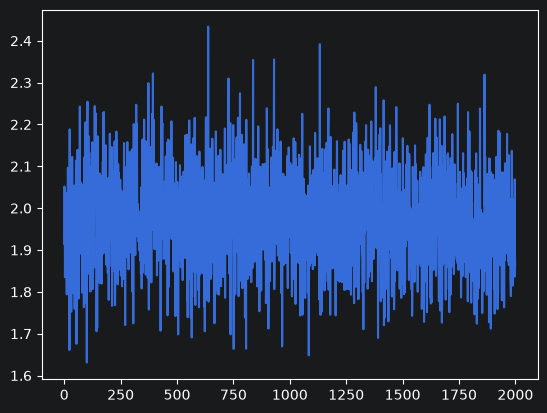

In [22]:
plt.plot(stepi, lossi)

In [23]:
emb = C[Xdev]
h = torch.tanh(emb.view(emb.shape[0],-1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1847, grad_fn=<NllLossBackward0>)

In [24]:
emb = C[Xtest]
h = torch.tanh(emb.view(emb.shape[0],-1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytest)
loss

tensor(2.2026, grad_fn=<NllLossBackward0>)

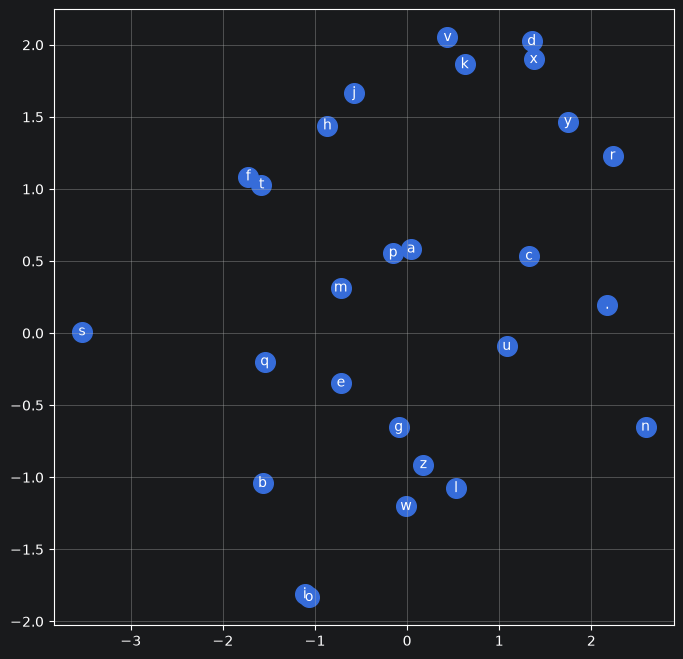

In [25]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [27]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
      emb = C[torch.tensor([context])]
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

dexten.
jalee.
kima.
kayden.
maimitta.
nylandr.
kata.
kremiyah.
javarii.
tai.
moriella.
kinzeredo.
kaley.
masade.
eniavion.
rashst.
huntel.
viah.
asukasprabellil.
pennaisa.
